# Solution: Outliers and Duplicates -- Diamonds Dataset

**Exercises from notebook `02_outliers_and_duplicates.ipynb`**

Jingxu Li - 320230942071


## Exercise 1: IQR Outlier Detection

Load the seaborn diamonds dataset. Use IQR to detect outliers in the price column. How many are flagged?


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../dataset/diamonds.csv')
print(f"Dataset shape: {df.shape}")

Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_iqr = df[(df['price'] < lower) | (df['price'] > upper)]
print(f"IQR bounds: lower={lower:.2f}, upper={upper:.2f}")
print(f"Outliers flagged by IQR: {len(outliers_iqr)} ({len(outliers_iqr)/len(df)*100:.2f}%)")



Dataset shape: (53940, 10)
IQR bounds: lower=-5611.38, upper=11885.62
Outliers flagged by IQR: 3540 (6.56%)


## Exercise 2: Isolation Forest vs IQR

Apply Isolation Forest with contamination=0.02. Do the flagged rows overlap with the IQR flags?


In [11]:
from sklearn.ensemble import IsolationForest

df['iqr_outlier'] = (df['price'] < lower) | (df['price'] > upper)

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
iso = IsolationForest(contamination=0.02, random_state=42)
df['iso_outlier'] = iso.fit_predict(df[num_cols])
df['iso_outlier'] = df['iso_outlier'] == -1

overlap = (df['iso_outlier'] & df['iqr_outlier']).sum()
iso_only = (df['iso_outlier'] & ~df['iqr_outlier']).sum()
iqr_only = (~df['iso_outlier'] & df['iqr_outlier']).sum()

print(f"IQR flags on price: {iqr_only + overlap}")
print(f"Isolation Forest flags on {len(num_cols)} numeric cols: {iso_only + overlap}")
print(f"Flagged by both methods: {overlap}")
print(f"Flagged by Isolation Forest only: {iso_only}")
print(f"Flagged by IQR only: {iqr_only}")
print(f"Overlap percentage (of IQR flags): {overlap / (iqr_only + overlap) * 100:.1f}%")
print("Overlap is small because IQR (univariate on price) and Isolation Forest")
print("(multivariate on all numeric columns) detect different kinds of outliers.")


IQR flags on price: 3540
Isolation Forest flags on 7 numeric cols: 1079
Flagged by both methods: 833
Flagged by Isolation Forest only: 246
Flagged by IQR only: 2707
Overlap percentage (of IQR flags): 23.5%
Overlap is small because IQR (univariate on price) and Isolation Forest
(multivariate on all numeric columns) detect different kinds of outliers.


## Exercise 3: Winsorization and R2

Winsorize price at the 1st and 99th percentiles. Compare the R2 of a linear regression model predicting price before and after winsorizing.


Original price -- R2: -0.6686 (+/- 2.8052)
Winsorized price -- R2: -0.6864 (+/- 2.8666)
Improvement: -0.0179


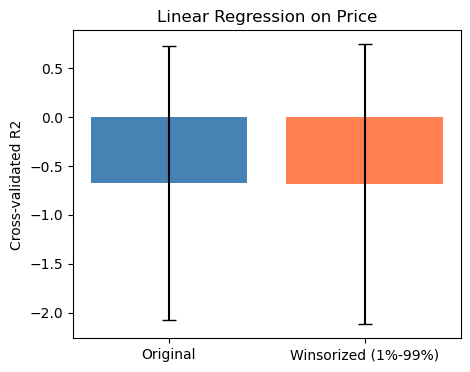

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from scipy.stats.mstats import winsorize

feature_cols = ['carat', 'depth', 'table', 'x', 'y', 'z']
X = df[feature_cols]
y_original = df['price'].values

price_winsorized = np.asarray(winsorize(df['price'].values, limits=[0.01, 0.01]))

pipe_original = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

pipe_winsorized = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

r2_orig = cross_val_score(pipe_original, X, y_original, cv=5, scoring='r2')
r2_win = cross_val_score(pipe_winsorized, X, price_winsorized, cv=5, scoring='r2')

print(f"Original price -- R2: {r2_orig.mean():.4f} (+/- {r2_orig.std() * 2:.4f})")
print(f"Winsorized price -- R2: {r2_win.mean():.4f} (+/- {r2_win.std() * 2:.4f})")
print(f"Improvement: {r2_win.mean() - r2_orig.mean():.4f}")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Original', 'Winsorized (1%-99%)'],
       [r2_orig.mean(), r2_win.mean()],
       yerr=[r2_orig.std(), r2_win.std()], capsize=5,
       color=['steelblue', 'coral'])
ax.set_ylabel('Cross-validated R2')
ax.set_title('Linear Regression on Price')
plt.show()


## Exercise 4: Inject and Remove Duplicates

The diamonds dataset has no true duplicates. Artificially inject 50 and verify your deduplication code removes them correctly.


In [12]:
print(f"Original shape: {df.shape}")

dup_rows = df.iloc[:50].copy()
df_augmented = pd.concat([df, dup_rows], ignore_index=True)
print(f"After injecting 50 duplicates: {df_augmented.shape}")
expected_dups = df.duplicated().sum()
print(f"Pre-existing duplicates in original data: {expected_dups}")
print(f"Total duplicates after injection: {df_augmented.duplicated().sum()}")

# Deduplicate
df_deduped = df_augmented.drop_duplicates(keep='first').reset_index(drop=True)
print(f"After deduplication: {df_deduped.shape}")
rows_removed = len(df_augmented) - len(df_deduped)
print(f"Total rows removed by dedup: {rows_removed}")
assert rows_removed == expected_dups + 50, (
    f"Expected to remove {expected_dups + 50} rows, removed {rows_removed}"
)
print("[OK] Deduplication removed all 50 injected + all pre-existing duplicates.")


Original shape: (53940, 12)
After injecting 50 duplicates: (53990, 12)
Pre-existing duplicates in original data: 146
Total duplicates after injection: 196
After deduplication: (53794, 12)
Total rows removed by dedup: 196
[OK] Deduplication removed all 50 injected + all pre-existing duplicates.
